In [ ]:
import polars as pl

1.39.0


In [20]:
import polars as pl

df = pl.read_parquet("transactions-2025-12.parquet")

df.head(10)
print(len(df))

3782447


In [7]:
print(df.select(pl.col("item_id").n_unique()))
print(df.select(pl.col("location").n_unique()))

shape: (1, 1)
┌─────────┐
│ item_id │
│ ---     │
│ u32     │
╞═════════╡
│ 13544   │
└─────────┘
shape: (1, 1)
┌──────────┐
│ location │
│ ---      │
│ u32      │
╞══════════╡
│ 1005     │
└──────────┘


# lọc theo location và item id

In [57]:
import polars as pl

df = pl.read_parquet("transactions-2025-12.parquet")

result = (
    df.group_by(["item_id", "location"])
      .agg(pl.len().alias("count"))
)

print(result)
n=len(result)
print(n)


shape: (1_167_571, 3)
┌───────────────┬──────────┬───────┐
│ item_id       ┆ location ┆ count │
│ ---           ┆ ---      ┆ ---   │
│ str           ┆ i32      ┆ u32   │
╞═══════════════╪══════════╪═══════╡
│ 4280000000041 ┆ 660      ┆ 1     │
│ 6798000000001 ┆ 144      ┆ 8     │
│ 3880000000002 ┆ 1076     ┆ 10    │
│ 0180000000011 ┆ 1049     ┆ 1     │
│ 2155000000151 ┆ 729      ┆ 1     │
│ …             ┆ …        ┆ …     │
│ 2344000000056 ┆ 539      ┆ 2     │
│ 4049000000001 ┆ 1132     ┆ 1     │
│ 1667000000001 ┆ 301      ┆ 1     │
│ 4597000000001 ┆ 1049     ┆ 1     │
│ 1155000000001 ┆ 624      ┆ 14    │
└───────────────┴──────────┴───────┘
1167571


# random 1 cặp bất kỳ

In [23]:
random_pair = result.sample(1)

print(random_pair)
item = random_pair["item_id"][0]
loc = random_pair["location"][0]

rows = df.filter(
    (pl.col("item_id") == item) &
    (pl.col("location") == loc)
).select(["item_id", "updated_date","quantity", "location"])

print(rows)

shape: (1, 3)
┌───────────────┬──────────┬───────┐
│ item_id       ┆ location ┆ count │
│ ---           ┆ ---      ┆ ---   │
│ str           ┆ i32      ┆ u32   │
╞═══════════════╪══════════╪═══════╡
│ 2746000000011 ┆ 113      ┆ 8     │
└───────────────┴──────────┴───────┘
shape: (8, 4)
┌───────────────┬─────────────────────────┬──────────┬──────────┐
│ item_id       ┆ updated_date            ┆ quantity ┆ location │
│ ---           ┆ ---                     ┆ ---      ┆ ---      │
│ str           ┆ datetime[μs]            ┆ i32      ┆ i32      │
╞═══════════════╪═════════════════════════╪══════════╪══════════╡
│ 2746000000011 ┆ 2025-12-08 08:49:32.930 ┆ 1        ┆ 113      │
│ 2746000000011 ┆ 2025-12-29 17:21:21.430 ┆ 1        ┆ 113      │
│ 2746000000011 ┆ 2025-12-29 15:13:24.527 ┆ 1        ┆ 113      │
│ 2746000000011 ┆ 2025-12-29 12:14:01.787 ┆ 1        ┆ 113      │
│ 2746000000011 ┆ 2025-12-27 17:11:15.627 ┆ 1        ┆ 113      │
│ 2746000000011 ┆ 2025-12-19 20:39:47.053 ┆ 1        

# transform

In [43]:
import polars as pl

# thêm cột day từ updated_date
df_day =  df.with_columns(
    pl.col("updated_date").dt.day().alias("day")
)

weeks = [7, 14, 21, 31]
data = []

for i, end_day in enumerate(weeks, start=1):
    total_quantity = df_day.filter(
        pl.col("day") <= end_day
    )["quantity"].sum()
    
    data.append((i, total_quantity))

# tạo bảng mới
df_week = pl.DataFrame(
    data,
    schema=["week", "quantity"]
)

print(df_week)

shape: (4, 2)
┌──────┬──────────┐
│ week ┆ quantity │
│ ---  ┆ ---      │
│ i64  ┆ i64      │
╞══════╪══════════╡
│ 1    ┆ 1395555  │
│ 2    ┆ 2955821  │
│ 3    ┆ 4276177  │
│ 4    ┆ 6157527  │
└──────┴──────────┘


C:\Users\ASUS\AppData\Local\Temp\ipykernel_33256\3483715059.py:19: DataOrientationWarning: Row orientation inferred during DataFrame construction. Explicitly specify the orientation by passing `orient="row"` to silence this warning.
  df_week = pl.DataFrame(


# train test split

In [44]:
from datetime import datetime


train = df_week.filter(pl.col("week") <= 3)
test  = df_week.filter(pl.col("week") >= 4)

print("train size:", len(train))
print("test size:", len(test))

train size: 3
test size: 1


# ve matplotlib

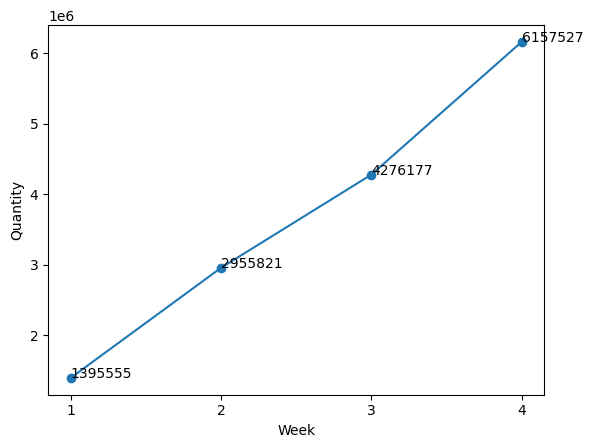

In [45]:
import matplotlib.pyplot as plt
x = df_week["week"].to_list()
y = df_week["quantity"].to_list()

plt.plot(x, y, marker="o")

for i, j in zip(x, y):
    plt.text(i, j, str(j))

plt.xticks([1,2,3,4])
plt.xlabel("Week")
plt.ylabel("Quantity")
plt.show()

# train mo hinh

In [48]:
X_train = train['week'].to_numpy().reshape(-1,1)
y_train=train['quantity']
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(X_train, y_train)
print(model.coef_, model.intercept_)

[1440311.] -4770.999999999069


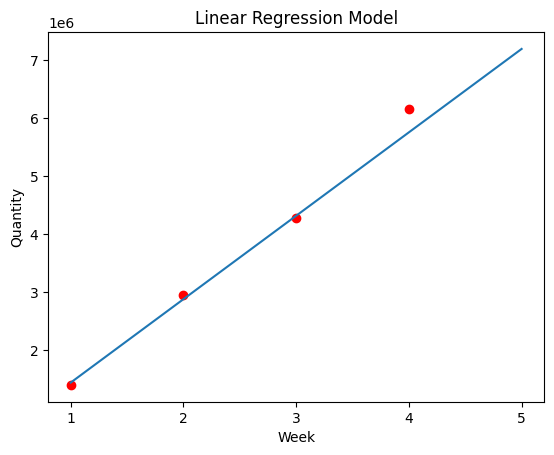

In [54]:
x = train["week"].to_numpy()
y = train["quantity"].to_numpy()
import numpy as np

# vẽ các điểm dữ liệu
plt.scatter(df_week['week'],df_week['quantity'], color='r')

# tạo đường regression
x_line = np.linspace(1, 5, 100)
y_line = model.coef_[0] * x_line + model.intercept_

# vẽ đường mô hình
plt.plot(x_line, y_line)

plt.xlabel("Week")
plt.ylabel("Quantity")
plt.title("Linear Regression Model")
plt.xticks([1,2,3,4,5])
plt.show()

In [56]:
from sklearn.metrics import mean_squared_error
X_test = test["week"].to_numpy().reshape(-1,1)
y_test=test['quantity']
y_pred=model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)

MSE: 160844310916.00073
